<a href="https://colab.research.google.com/github/davidshtengel/ds3001-final/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking
from tensorflow.keras.utils import to_categorical


In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving prepared_congress_trading_dataset.csv to prepared_congress_trading_dataset (3).csv


,Unnamed: 0,Ticker,Traded,Transaction,Trade_Size_USD,Name,Filed,Party,District,Chamber,State
0,0,NGL,2024-03-11,Sale,"$15,001 - $50,000",Mark Dr Green,2024-03-13,R,TN07,House,Tennessee
1,1,FCX,2024-02-29,Sale,"$1,001 - $15,000",Josh Gottheimer,2024-03-07,D,NJ05,House,New Jersey
2,2,V,2024-02-29,Purchase,"$1,001 - $15,000",Pete Sessions,2024-03-07,R,TX17,House,Texas
3,3,AAPL,2024-02-29,Purchase,"$1-$1,000",Pete Sessions,2024-02-29,R,TX17,House,Texas
4,4,MSFT,2024-02-29,Sale,"$100,001 - $250,000",Suzan K. Delbene,2024-03-08,D,WA01,House,Washington


In [ ]:
df = df[df['Party'].isin(['D', 'R'])].copy()

# Convert dates
df['Traded'] = pd.to_datetime(df['Traded'], errors='coerce')
df['Filed'] = pd.to_datetime(df['Filed'], errors='coerce')
df['Month'] = df['Traded'].dt.month

# Year
df['Year'] = df['Traded'].dt.year

# Days between trade and filing
df['Days_To_File'] = (df['Filed'] - df['Traded']).dt.days


size_map = {
    '$1 - $1,000': 0,
    '$1,001 - $15,000': 1,
    '$15,001 - $50,000': 2,
    '$50,001 - $100,000': 3,
    '$100,001 - $250,000': 4,
    '$250,001 - $500,000': 5,
    '$500,001 - $1,000,000': 6,
    '$1,000,001 - $5,000,000': 7,
    '$5,000,001 - $25,000,000': 8,
    '$25,000,001 - $50,000,000': 9
}

df['Size_Number'] = df['Trade_Size_USD'].map(size_map)

df = df.sort_values(['Name', 'Traded'])


feature_cols = ['Ticker', 'Transaction', 'Chamber', 'Month',
                'Days_To_File', 'Size_Number']


encoders = {}
for col in ['Ticker', 'Transaction', 'Chamber','Month']:
    enc = LabelEncoder()
    df[col] = enc.fit_transform(df[col].astype(str))
    encoders[col] = enc


df['Days_To_File'] = df['Days_To_File'].fillna(df['Days_To_File'].median())
df['Size_Number'] = df['Size_Number'].fillna(df['Size_Number'].median())


party_encoder = LabelEncoder()
df['PartyLabel'] = party_encoder.fit_transform(df['Party'])

# Building sequences
sequences = []
labels = []

for name, group in df.groupby('Name'):
    seq = group[feature_cols].values.astype('float32')
    label = group['PartyLabel'].iloc[0]
    sequences.append(seq)
    labels.append(label)

# Pad sequences
max_len = max(len(s) for s in sequences)
X = pad_sequences(sequences, maxlen=max_len, padding='pre', dtype='float32')

# One-hot labels
y = to_categorical(labels)
num_classes = len(party_encoder.classes_)

X.shape, y.shape



((334, 2758, 6), (334, 2))

In [ ]:
df

,Unnamed: 0,Ticker,Traded,Transaction,Trade_Size_USD,Name,Filed,Party,District,Chamber,State,Month,Year,Days_To_File,Size_Number,PartyLabel
5626,5655,2036,2022-09-01,1,"$1,001 - $15,000",Abigail Spanberger,2022-09-04,D,VA07,0,Virginia,11,2022,3,1.0,0
3890,3912,2036,2023-03-02,2,"$1,001 - $15,000",Abigail Spanberger,2023-03-03,D,VA07,0,Virginia,5,2023,1,1.0,0
9628,9663,19,2021-07-23,2,"$1,001 - $15,000",Adam B. Schiff,2021-07-30,D,CA28,0,California,9,2021,7,1.0,0
8302,8335,19,2021-12-13,2,"$15,001 - $50,000",Adam B. Schiff,2021-12-21,D,CA28,0,California,3,2021,8,2.0,0
37318,37390,2138,2016-05-05,1,"$1,001 - $15,000",Adam Kinzinger,2016-07-14,R,IL16,0,Illinois,7,2016,70,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2785,2804,3656,2023-05-26,2,"$1,001 - $15,000",Zoe Lofgren,2023-06-06,D,CA18,0,California,7,2023,11,1.0,0
2786,2805,834,2023-05-26,2,"$1,001 - $15,000",Zoe Lofgren,2023-06-06,D,CA18,0,California,7,2023,11,1.0,0
2787,2806,937,2023-05-26,2,"$1,001 - $15,000",Zoe Lofgren,2023-06-06,D,CA18,0,California,7,2023,11,1.0,0
2788,2807,556,2023-05-26,2,"$1,001 - $15,000",Zoe Lofgren,2023-06-06,D,CA18,0,California,7,2023,11,1.0,0


In [ ]:
num_classes = len(party_encoder.classes_)

model = Sequential([
    Masking(mask_value=0., input_shape=(max_len, len(feature_cols))),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='sigmoid')
])

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, 2758, 6)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,322 (79.38 KB)

 Trainable params: 20,322 (79.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X, y,
    epochs=10,
    batch_size=8,
    validation_split=0.2
)


Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.6313 - loss: 0.6461 - val_accuracy: 0.4179 - val_loss: 0.7140
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.6644 - loss: 0.6117 - val_accuracy: 0.5522 - val_loss: 0.7112
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.6265 - loss: 0.6122 - val_accuracy: 0.5821 - val_loss: 0.7111
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.6231 - loss: 0.5954 - val_accuracy: 0.4328 - val_loss: 0.7334
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6552 - loss: 0.6126 - val_accuracy: 0.4179 - val_loss: 0.7346
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.6565 - loss: 0.6151 - val_accuracy: 0.5672 - val_loss: 0.7203
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.6187 - loss: 0.6172 - val_accuracy: 0.6119 - val_loss: 0.7107
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.6246 - loss: 0.5985 - val_accuracy: 0.4627 - val_loss:

In [ ]:
pred_probs = model.predict(X)
pred_labels = np.argmax(pred_probs, axis=1)
pred_parties = party_encoder.inverse_transform(pred_labels)

# Show first 10 predicted parties
pred_parties[:10]


11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 340ms/step


array(['D', 'D', 'R', 'D', 'D', 'D', 'R', 'D', 'R', 'R'], dtype=object)

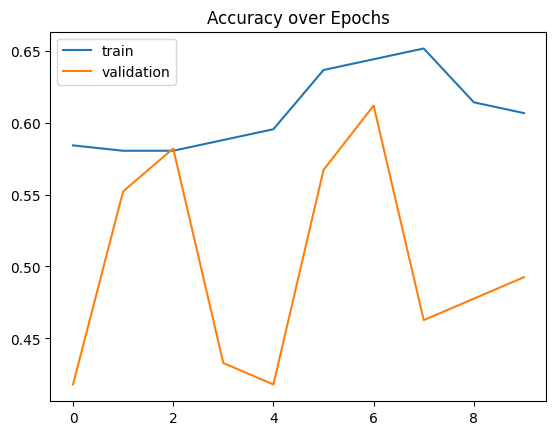

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.title("Accuracy over Epochs")
plt.show()


In [27]:
import tensorflow as tf
from tensorflow.keras.layers import Masking, LSTM, Dense, Dropout, Bidirectional

model = Sequential([
    Masking(mask_value=0., input_shape=(max_len, len(feature_cols))),
    LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3),
    LSTM(64, dropout=0.3, recurrent_dropout=0.3),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')   # 2 outputs for binary classification
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X, y,
    epochs=25,
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=4,
            restore_best_weights=True
        )
    ]
)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_6 (Masking)             │ (None, 2758, 6)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 2758, 128)      │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,834 (487.63 KB)

 Trainable params: 124,834 (487.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 112s 11s/step - accuracy: 0.4649 - loss: 0.7211 - val_accuracy: 0.5672 - val_loss: 0.6937
Epoch 2/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 139s 11s/step - accuracy: 0.5000 - loss: 0.7528 - val_accuracy: 0.4179 - val_loss: 0.7001
Epoch 3/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 101s 11s/step - accuracy: 0.4972 - loss: 0.7102 - val_accuracy: 0.4030 - val_loss: 0.7092
Epoch 4/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 100s 11s/step - accuracy: 0.5335 - loss: 0.6916 - val_accuracy: 0.4179 - val_loss: 0.7028
Epoch 5/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 142s 11s/step - accuracy: 0.4752 - loss: 0.7079 - val_accuracy: 0.3731 - val_loss: 0.6999
